In [2]:
import yfinance as yf
from joblib import Memory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up cache to avoid redundant data fetches
cache_dir = './cache'
memory = Memory(location=cache_dir, verbose=0)

@memory.cache
def fetch_stock_data(ticker):
  """Fetch historical data for a given ticker."""
  try:
    ticker_obj = yf.Ticker(ticker)
    data = ticker_obj.history(period="10y")

    # Fetching Financials
    financials = ticker_obj.financials
    balance_sheet = ticker_obj.balance_sheet
    cash_flow = ticker_obj.cashflow

    # Fetching Dividends and Splits
    dividends = ticker_obj.dividends
    splits = ticker_obj.splits

    # Fetching general company info
    info = ticker_obj.info

    # Packaging everything into a dictionary
    all_data = {
      'historical_data': data,
      'financials': financials,
      'balance_sheet': balance_sheet,
      'cash_flow': cash_flow,
      'dividends': dividends,
      'splits': splits,
      'info': info
    }
    return all_data
  except Exception as e:
    print(f"Error fetching data for {ticker}: {str(e)}")
    return None

/Users/meetg/Desktop/Practice/stock_scope/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Define Stock List and Fetch Data

stock_list = [
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM', 'ORCL',  # Technology
    'JNJ', 'PFE', 'MRK', 'ABT', 'BMY', 'TMO',        # Healthcare
    'JPM', 'BAC', 'GS', 'MS', 'C', 'WFC',            # Financials
    'AMZN', 'TSLA', 'NKE', 'HD', 'MCD', 'BKNG',      # Consumer Discretionary
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'KHC',         # Consumer Staples
    'XOM', 'CVX', 'SLB', 'COP', 'PSX', 'MPC',        # Energy
    'BA', 'HON', 'MMM', 'CAT', 'GE', 'DE',           # Industrials
    'VZ', 'T', 'CMCSA', 'TMUS', 'CHTR',              # Communication Services
    'AMT', 'SPG', 'EQIX', 'O', 'CCI'                 # Real Estate
]

# Dictionary to store data for each stock
all_stock_data = {}

# Fetch and store data for each stock
for ticker in stock_list:
  all_stock_data[ticker] = fetch_stock_data(ticker)

print("Data fetched successfully for all stocks!")

Data fetched successfully for all stocks!


In [4]:
# Cell 5: Handling Missing Values and Outliers

def clean_and_preprocess(all_stock_data):
    cleaned_data = {}
    
    for ticker, data in all_stock_data.items():
        historical_data = data['historical_data']
        
        # Handling missing values
        historical_data = historical_data.dropna()
        
        # Handling outliers
        historical_data = historical_data[historical_data['Volume'] < historical_data['Volume'].quantile(0.99)]
        historical_data = historical_data[historical_data['Volume'] > historical_data['Volume'].quantile(0.01)]
        
        # Feature engineering: Adding moving averages
        historical_data['20-Day MA'] = historical_data['Close'].rolling(window=20).mean()
        historical_data['50-Day MA'] = historical_data['Close'].rolling(window=50).mean()
        historical_data['200-Day MA'] = historical_data['Close'].rolling(window=200).mean()
        
        cleaned_data[ticker] = historical_data
    
    return cleaned_data

cleaned_stock_data = clean_and_preprocess(all_stock_data)

# Example: Display the cleaned and preprocessed data for AAPL
print(cleaned_stock_data['AAPL'].head())

                                Open       High        Low      Close  \
Date                                                                    
2014-05-15 00:00:00-04:00  18.786894  18.846915  18.576501  18.601141   
2014-05-16 00:00:00-04:00  18.595138  18.876295  18.493102  18.875664   
2014-05-19 00:00:00-04:00  18.886410  19.185888  18.869982  19.099331   
2014-05-20 00:00:00-04:00  19.096801  19.156506  18.977388  19.103119   
2014-05-21 00:00:00-04:00  19.075311  19.165975  19.019397  19.153656   

                              Volume  Dividends  Stock Splits  20-Day MA  \
Date                                                                       
2014-05-15 00:00:00-04:00  230846000        0.0           0.0        NaN   
2014-05-16 00:00:00-04:00  276256400        0.0           0.0        NaN   
2014-05-19 00:00:00-04:00  317755200        0.0           0.0        NaN   
2014-05-20 00:00:00-04:00  234836000        0.0           0.0        NaN   
2014-05-21 00:00:00-04:00  19685

In [5]:
def clean_and_preprocess(all_stock_data):
    cleaned_data = {}
    all_nan_rows = {}

    for ticker, data in all_stock_data.items():
        historical_data = data['historical_data']

        # Handling missing values
        historical_data = historical_data.dropna()

        # Handling outliers
        historical_data = historical_data[historical_data['Volume'] < historical_data['Volume'].quantile(0.99)]
        historical_data = historical_data[historical_data['Volume'] > historical_data['Volume'].quantile(0.01)]

        # Feature engineering: Adding moving averages
        historical_data['20-Day MA'] = historical_data['Close'].rolling(window=20).mean()
        historical_data['50-Day MA'] = historical_data['Close'].rolling(window=50).mean()
        historical_data['200-Day MA'] = historical_data['Close'].rolling(window=200).mean()

        # Identify rows with NaN values
        nan_rows = historical_data[historical_data[['20-Day MA', '50-Day MA', '200-Day MA']].isna().any(axis=1)]

        # Dropping rows with NaN values resulting from moving averages
        historical_data = historical_data.dropna()

        # Store cleaned data and nan rows
        cleaned_data[ticker] = historical_data
        all_nan_rows[ticker] = nan_rows

    return all_nan_rows, cleaned_data

# Fetching nan rows and cleaned data
nan_rows, cleaned_stock_data = clean_and_preprocess(all_stock_data)

# Example: Display rows with NaN values for AAPL
print("Rows with NaN values for AAPL:")
print(nan_rows['AAPL'])

# Example: Display the cleaned and preprocessed data for AAPL
print("Cleaned data for AAPL:")
print(cleaned_stock_data['AAPL'].head())

Rows with NaN values for AAPL:
                                Open       High        Low      Close  \
Date                                                                    
2014-05-15 00:00:00-04:00  18.786894  18.846915  18.576501  18.601141   
2014-05-16 00:00:00-04:00  18.595138  18.876295  18.493102  18.875664   
2014-05-19 00:00:00-04:00  18.886410  19.185888  18.869982  19.099331   
2014-05-20 00:00:00-04:00  19.096801  19.156506  18.977388  19.103119   
2014-05-21 00:00:00-04:00  19.075311  19.165975  19.019397  19.153656   
...                              ...        ...        ...        ...   
2015-03-05 00:00:00-05:00  28.811985  28.850077  28.180084  28.325735   
2015-03-06 00:00:00-05:00  28.771647  28.989003  28.292121  28.368307   
2015-03-09 00:00:00-04:00  28.673059  29.033827  28.023232  28.489315   
2015-03-10 00:00:00-04:00  28.325733  28.507236  27.740889  27.899984   
2015-03-11 00:00:00-04:00  27.953770  27.958250  27.362203  27.391333   

                   

In [6]:
ticker = 'AAPL'

# Calculate moving averages and identify NaN rows
def calculate_moving_averages(data):
    data['20-Day MA'] = data['Close'].rolling(window=20).mean()
    data['50-Day MA'] = data['Close'].rolling(window=50).mean()
    data['200-Day MA'] = data['Close'].rolling(window=200).mean()
    nan_rows = data[data[['20-Day MA', '50-Day MA', '200-Day MA']].isna().any(axis=1)]
    return data, nan_rows

# Copy of historical data for analysis
historical_data = all_stock_data[ticker]['historical_data'].copy()
historical_data, nan_rows = calculate_moving_averages(historical_data)

# Display the NaN rows
print("Rows with NaN values in moving averages:")
print(nan_rows)

# Further inspect the data points leading up to the first NaN row for 20-Day MA
num_days_to_inspect = 25  # Inspecting a few more days beyond the window period
inspection_start_date = nan_rows.index[0] - pd.Timedelta(days=num_days_to_inspect)
inspection_data = historical_data.loc[inspection_start_date:nan_rows.index[0]]

print("Data leading up to the first NaN row for 20-Day MA:")
print(inspection_data)


Rows with NaN values in moving averages:
                                Open       High        Low      Close  \
Date                                                                    
2014-05-15 00:00:00-04:00  18.786894  18.846915  18.576501  18.601141   
2014-05-16 00:00:00-04:00  18.595138  18.876295  18.493102  18.875664   
2014-05-19 00:00:00-04:00  18.886410  19.185888  18.869982  19.099331   
2014-05-20 00:00:00-04:00  19.096801  19.156506  18.977388  19.103119   
2014-05-21 00:00:00-04:00  19.075311  19.165975  19.019397  19.153656   
...                              ...        ...        ...        ...   
2015-02-23 00:00:00-05:00  29.134652  29.802404  29.053984  29.802404   
2015-02-24 00:00:00-05:00  29.788970  29.936862  29.392350  29.616428   
2015-02-25 00:00:00-05:00  29.479733  29.488698  28.715626  28.859035   
2015-02-26 00:00:00-05:00  28.859035  29.325118  28.370546  29.224283   
2015-02-27 00:00:00-05:00  29.130178  29.257904  28.735802  28.785099   

         

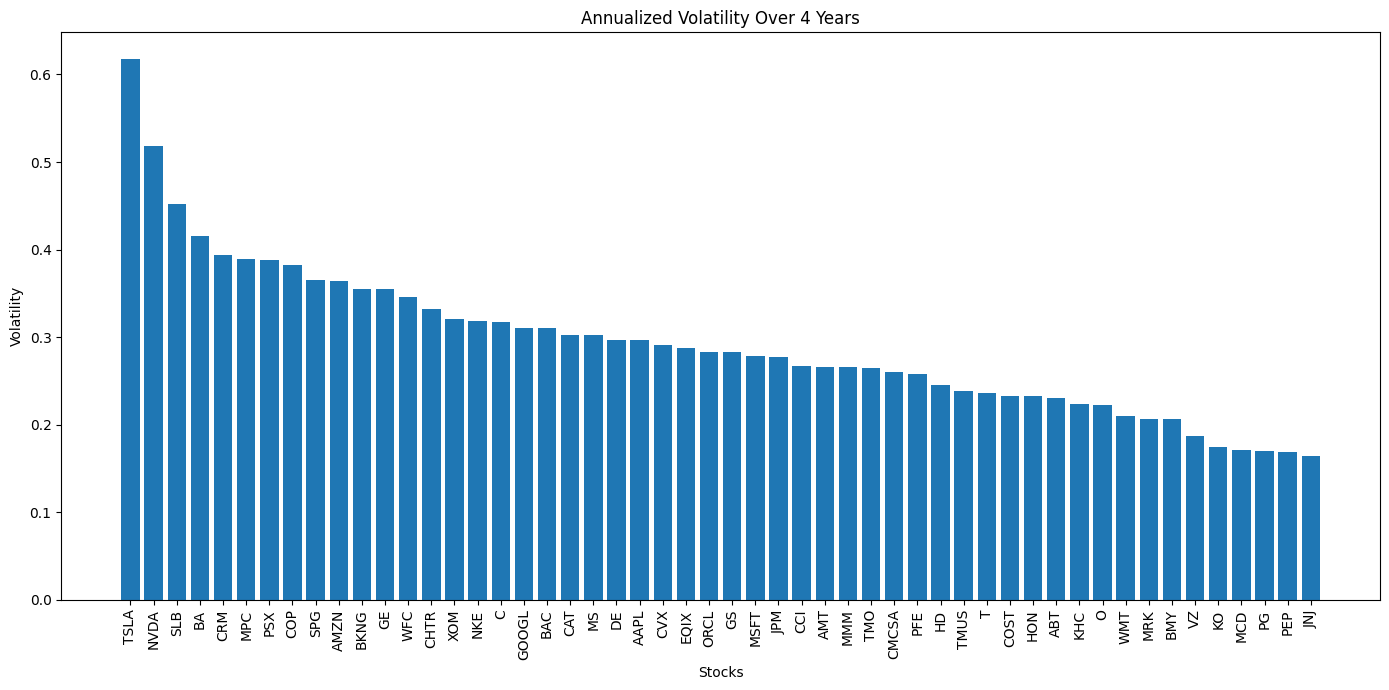

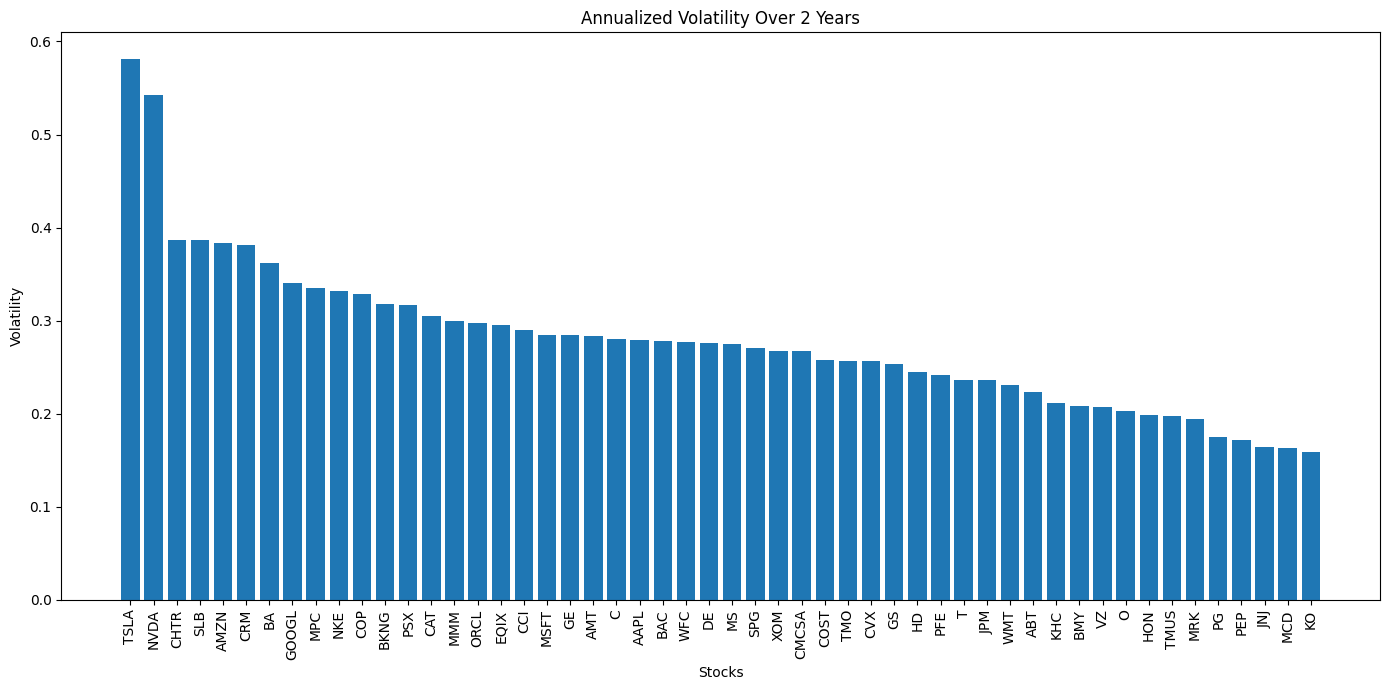

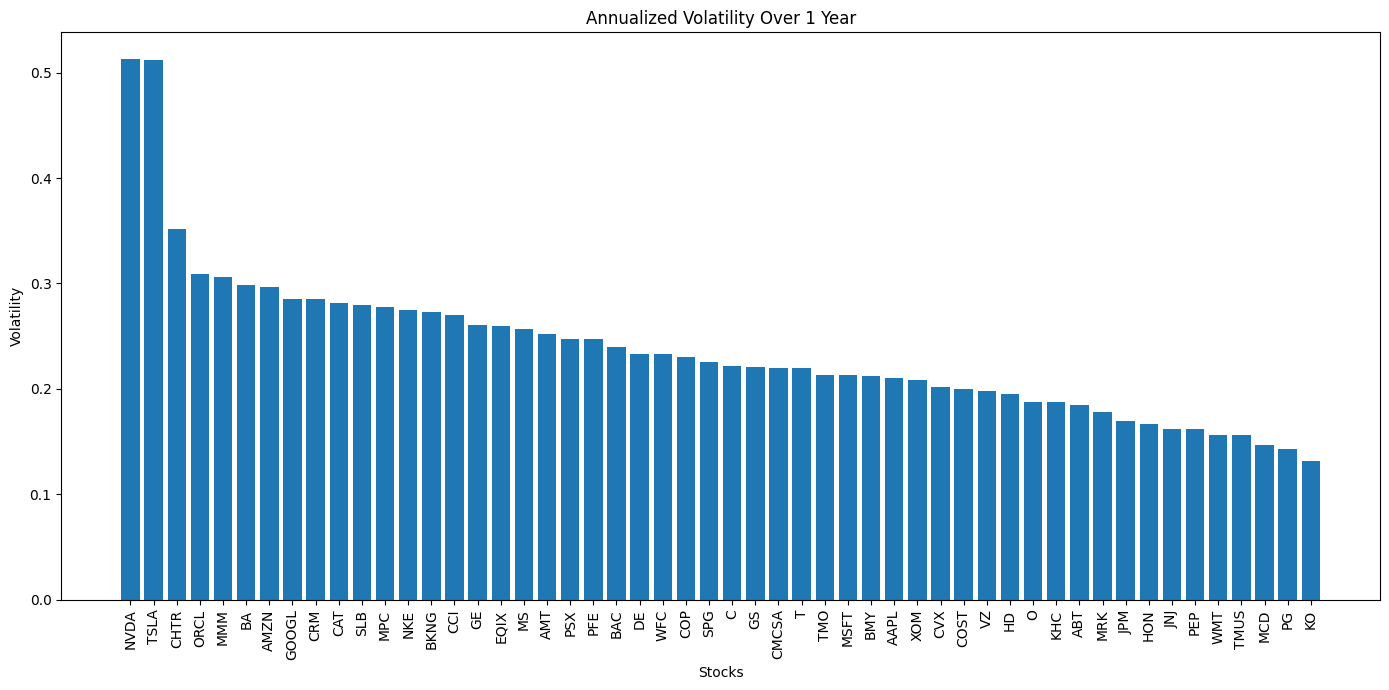

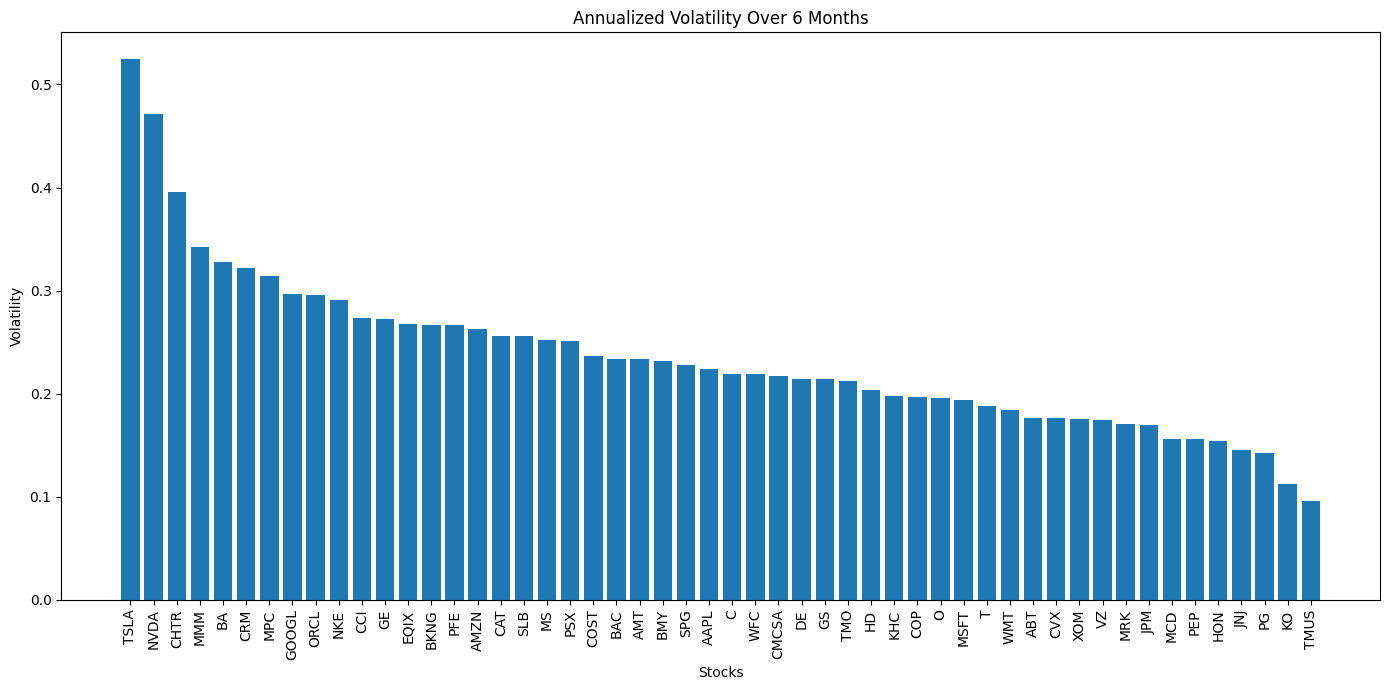

In [13]:
def calculate_volatility(data):
    # Calculate daily returns
    data.loc[:, 'Daily Return'] = data['Close'].pct_change()
    
    # Compute annualized volatility
    volatility = data['Daily Return'].std() * np.sqrt(252)
    return volatility

def get_time_frame_data(cleaned_stock_data, end_date, period_days):
    start_date = end_date - pd.Timedelta(days=period_days)
    
    time_frame_data = {}
    for ticker, data in cleaned_stock_data.items():
        # Ensure both start_date and end_date match the timezone of the DataFrame index
        if data.index.tz is not None:
            if start_date.tzinfo is None:
                start_date = start_date.tz_localize(data.index.tz)
            else:
                start_date = start_date.tz_convert(data.index.tz)
                
            if end_date.tzinfo is None:
                end_date = end_date.tz_localize(data.index.tz)
            else:
                end_date = end_date.tz_convert(data.index.tz)
        else:
            start_date = start_date.tz_localize(None)
            end_date = end_date.tz_localize(None)
        
        time_frame_data[ticker] = data[(data.index >= start_date) & (data.index <= end_date)].copy()  # Use .copy() to avoid SettingWithCopyWarning
    
    return time_frame_data

def calculate_volatility_for_all_stocks(cleaned_stock_data, end_date, period_days):
    time_frame_data = get_time_frame_data(cleaned_stock_data, end_date, period_days)
    volatilities = {ticker: calculate_volatility(data) for ticker, data in time_frame_data.items()}
    return volatilities

# Set end date and periods
end_date = pd.to_datetime("2024-05-10").tz_localize('America/New_York')  # Ensure end_date is timezone-aware
periods = {
    "4 Years": 4 * 365,
    "2 Years": 2 * 365,
    "1 Year": 365,
    "6 Months": 6 * 30
}

# Calculate volatilities for each period
volatility_results = {period: calculate_volatility_for_all_stocks(cleaned_stock_data, end_date, days) for period, days in periods.items()}

def plot_volatility(volatility_results):
    for period, volatilities in volatility_results.items():
        # Sort volatilities in descending order
        sorted_volatilities = dict(sorted(volatilities.items(), key=lambda item: item[1], reverse=True))
        
        plt.figure(figsize=(14, 7))
        plt.bar(sorted_volatilities.keys(), sorted_volatilities.values())
        plt.xticks(rotation=90)
        plt.title(f"Annualized Volatility Over {period}")
        plt.xlabel("Stocks")
        plt.ylabel("Volatility")
        plt.tight_layout()
        plt.show()

# Plot volatilities
plot_volatility(volatility_results)

In [ ]:
#